ARTI308 - Machine Learning

# Lab 4: Data Quality Assessment & Preprocessing
## Supermarket Sales Dataset

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![img/step2.png](img/step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## 1. Load Dataset

In [2]:
# pd.set_option("display.max_columns",None)
df = pd.read_csv("supermarket_sales.csv")

In [3]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Date` should be datetime
- `Total` should be numeric

In [4]:
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

In [6]:
df.dtypes

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                               object
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object

In [7]:
df['Total'] = df['Total'].replace(r'[\$,]', '', regex=True)

In [8]:
df['Total'] = pd.to_numeric(df['Total'])

In [9]:
df.dtypes

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                               object
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object

We observe that some columns are stored as object type.
`Date` may not yet be in the correct format.
Incorrect data types can prevent proper calculations and time-based analysis.

Now `Date` is correctly stored as *datetime64*.
Numeric columns like `Total`, `Unit price`, and `Quantity` are already in the correct format.
This allows us to perform time-based grouping and numerical calculations correctly.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [10]:
df.isna()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df.isna().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

The output shows whether any column contains missing values.
If all values are zero, the dataset is complete.
If any column contains missing values, we must handle them.

### 3.2 Demonstration: Introduce Artificial Missing Values
### Why?

Since our dataset has no missing values, we introduce artificial ones *for learning purposes*.

we will be running this line:

`df_missing.loc[0:5, 'Amount'] = np.nan`


- `df_missing`: The pandas DataFrame you are modifying.

- `.loc[0:5, 'Amount']`: This uses the label-based indexer to select specific rows and columns.

- `0:5`: Selects rows with index labels 0, 1, 2, 3, 4, and 5. In label-based indexing, the end index is inclusive.

- `'Amount'`: Selects the column named 'Amount'.

- `= np.nan`: Assigns the value np.nan (which stands for "Not a Number") to all the selected cells. This is the standard way to represent missing or null values in numerical columns in pandas. The column's data type will be converted to float

In [12]:
df2 = df.copy()
df2.loc[0:5, 'Total'] = np.nan

In [13]:
df2.isna().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      6
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Now the Total column contains missing values.

In [14]:
df2.head(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,NaN,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,NaN,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,NaN,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,NaN,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,NaN,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,29.8865,NaN,2019-03-25,18:30,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.692,2019-02-25,14:36,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.380,2019-02-24,11:38,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,A,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.146,2019-01-10,17:15,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,B,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.746,2019-02-20,13:27,Credit card,164.52,4.761905,8.2260,5.9


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [15]:
df_remove = df2.dropna()

In [16]:
print('df with NaN: ',df2.shape)
print('df without NaN: ',df_remove.shape)

df with NaN:  (1000, 17)
df without NaN:  (994, 17)


In [17]:
df_remove.isna().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

The dataset now has fewer rows.
If only a small portion of data was missing, this method is acceptable.

However, removing too many rows can reduce model performance.

### Strategy 2: Mean Imputation

![img/Mean.png](img/Mean.png)

The mean represents the average value.
It is commonly used for normally distributed data.

In [18]:
df_mean = df2.copy()
df_mean['Total'].fillna(df_mean['Total'].mean(), inplace=True)

In [19]:
df_mean.head(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,322.179063,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,322.179063,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,322.179063,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,322.179063,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,322.179063,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,29.8865,322.179063,2019-03-25,18:30,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.692000,2019-02-25,14:36,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.380000,2019-02-24,11:38,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,A,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.146000,2019-01-10,17:15,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,B,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.746000,2019-02-20,13:27,Credit card,164.52,4.761905,8.2260,5.9


Missing values are now replaced with the average revenue.
This preserves dataset size but may reduce variability.
Mean imputation is sensitive to outliers.

### Strategy 3: Median Imputation

![img/median_formula_2.png](img/median_formula_2.png)
The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [20]:
df_median = df2.copy()
df_median['Total'].fillna(df_median['Total'].median(), inplace=True)

In [21]:
df_median.head(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,253.386,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,253.386,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,253.386,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,253.386,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,253.386,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,29.8865,253.386,2019-03-25,18:30,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.692,2019-02-25,14:36,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.380,2019-02-24,11:38,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,A,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.146,2019-01-10,17:15,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,B,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.746,2019-02-20,13:27,Credit card,164.52,4.761905,8.2260,5.9


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using IQR method.

![img/IQR.png](img/IQR.png)

In [22]:
import matplotlib.pyplot as plt

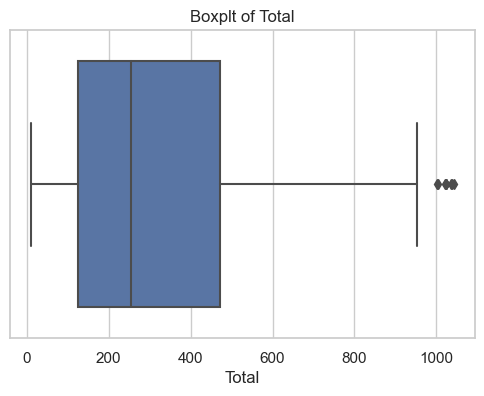

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Total'])

plt.title('Boxplt of Total')
plt.show()

Points outside the whiskers represent potential outliers.
These extreme revenue values may influence model predictions.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [24]:
Q1 = df['Total'].quantile(0.25)
Q3 = df['Total'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Total'] < lower) | (df['Total'] > upper)]
outliers.head(15)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
166,234-65-2137,C,Naypyitaw,Normal,Male,Home and lifestyle,95.58,10,47.790,1003.590,2019-01-16,13:32,Cash,955.8,4.761905,47.790,4.8
167,687-47-8271,A,Yangon,Normal,Male,Fashion accessories,98.98,10,49.490,1039.290,2019-02-08,16:20,Credit card,989.8,4.761905,49.490,8.7
350,860-79-0874,C,Naypyitaw,Member,Female,Fashion accessories,99.30,10,49.650,1042.650,2019-02-15,14:53,Credit card,993.0,4.761905,49.650,6.6
357,554-42-2417,C,Naypyitaw,Normal,Female,Sports and travel,95.44,10,47.720,1002.120,2019-01-09,13:45,Cash,954.4,4.761905,47.720,5.2
422,271-88-8734,C,Naypyitaw,Member,Female,Fashion accessories,97.21,10,48.605,1020.705,2019-02-08,13:00,Credit card,972.1,4.761905,48.605,8.7
557,283-26-5248,C,Naypyitaw,Member,Female,Food and beverages,98.52,10,49.260,1034.460,2019-01-30,20:23,Ewallet,985.2,4.761905,49.260,4.5
699,751-41-9720,C,Naypyitaw,Normal,Male,Home and lifestyle,97.50,10,48.750,1023.750,2019-01-12,16:18,Ewallet,975.0,4.761905,48.750,8.0
792,744-16-7898,B,Mandalay,Normal,Female,Home and lifestyle,97.37,10,48.685,1022.385,2019-01-15,13:48,Credit card,973.7,4.761905,48.685,4.9
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.690,1022.490,2019-03-02,17:16,Ewallet,973.8,4.761905,48.690,4.4


The output displays records considered extreme based on statistical boundaries.
These may be valid high-value transactions or potential data errors.

### Remove Outliers
We remove values outside the acceptable range.

In [23]:
df_no_outliers = df[(df['Total'] >= lower) & (df['Total'] <= upper)]

print('df with outliers: ',df.shape)
print('df without outliers: ',df_no_outliers.shape)

df with outliers:  (1000, 17)
df without outliers:  (991, 17)


The dataset size is slightly reduced.
Removing outliers reduces distortion but may also remove important rare events.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but important real-world events.  
For example, in a sales dataset, a very large transaction might correspond to a bulk corporate order or a seasonal promotion.  

If we remove such values blindly, we may lose valuable information and bias the analysis.

Before removing outliers, we should always ask:
- Is this value a data entry mistake?
- Or is it a valid but rare observation?

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

![img/percentile.png](img/percentile.png)

In [24]:
lower_cap = df['Total'].quantile(0.05) # 5%
upper_cap = df['Total'].quantile(0.95) # 95%

df_capped = df.copy()
df_capped['Total'] = df_capped['Total'].clip(lower_cap, upper_cap)

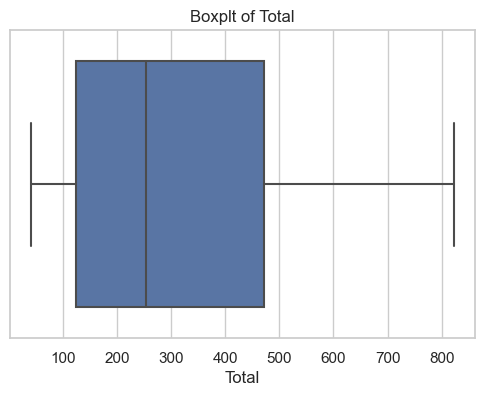

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['Total'])

plt.title('Boxplt of Total')
plt.show()

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

It works using the formula:
![img/min_max.png](img/min_max.png)

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

In [26]:
df[['Total','Quantity']].head()

,Total,Quantity
0,548.9715,7
1,80.2200,5
2,340.5255,7
3,489.0480,8
4,634.3785,7


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Total', 'Quantity']].copy()

df_scaled[['Total', 'Quantity']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Total,Quantity
0,0.521616,0.666667
1,0.067387,0.444444
2,0.319628,0.666667
3,0.463549,0.777778
4,0.604377,0.666667


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Importantly, normalization does NOT change the relative relationships between data points.
If one transaction originally had higher revenue than another, it will still have a higher normalized value.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:

![img/zscore.png](img/zscore.png)

This method keeps the shape of the distribution but rescales it around zero.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Total', 'Quantity']].copy()

df_standardized[['Total', 'Quantity']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Total,Quantity
0,0.919607,0.509930
1,-0.987730,-0.174540
2,0.071446,0.509930
3,0.675780,0.852165
4,1.267125,0.509930


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

The standard deviation of each feature becomes approximately 1, meaning the spread of the data is standardized.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful 
because we can combine correlated features into fewer components.

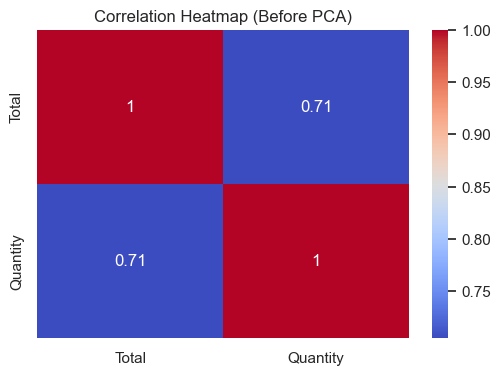

In [29]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Total','Quantity']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The heatmap shows the correlation between the numerical features:

- The diagonal values are 1 because each feature is perfectly correlated with itself.
- The correlation between `Total` and `Boxes Shipped` is approximately *-0.013*.

A correlation value close to 0 indicates that there is almost **NO linear** relationship between the two features.

This means that `Total` and `Boxes Shipped` do not move together in a predictable linear pattern.

Since PCA is most useful when features are strongly correlated, 
the benefit of dimensionality reduction in this case may be limited.

Therefore, applying PCA here is mainly for demonstration purposes rather than necessity.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

### Visual Intuition

Imagine we have two features:

X1 = Amount  
X2 = Boxes Shipped  

If we plot the data points, they may look like this:

              X2
               |
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1

Notice that the points follow a diagonal pattern.
This means the two features are correlated and contain overlapping information.

Instead of keeping both X1 and X2 separately,
PCA finds the direction where the data varies the most.

That direction becomes **Principal Component 1 (PC1)**.

              X2
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1
                    \
                     \
                      \
                       \
                        → PC1 (maximum variance direction)

PC2 is the direction perpendicular to PC1.

If most of the variation is along PC1,
then PC1 alone captures most of the dataset’s information.

In that case, we can reduce:

2 features → 1 feature (PC1)

while keeping most of the variance.

In [30]:
from sklearn.decomposition import PCA

X = df_standardized[['Total', 'Quantity']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.85275509 0.14724491]


The `Explained Variance Ratio` indicates how much of the total information (variance) is captured by each principal component.

For example:
- If PC1 explains 85% of the variance, it means that one new feature already summarizes most of the dataset's information.
- If PC1 and PC2 together explain nearly 100%, then very little information is lost.

When most of the variance is captured by fewer components, dimensionality reduction is considered effective.

This helps simplify models, reduce computational cost, and sometimes improve generalization performance.

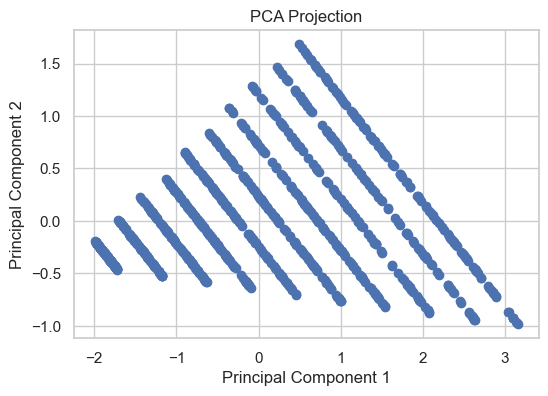

In [31]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one sales transaction.

The axes no longer represent the original features (`Total` and `Boxes Shipped`).
Instead:

- The horizontal axis represents Principal Component 1 (PC1).
- The vertical axis represents Principal Component 2 (PC2).

PC1 captures the direction of maximum variance in the data.
PC2 captures the second most important direction, perpendicular to PC1.

The spread of points along the horizontal direction indicates how much variation is captured by PC1.
If most of the spread appears horizontally, it suggests that PC1 captures most of the dataset's information.

This projection allows us to visualize high-dimensional data in a lower-dimensional space.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA only if the numerical features show a correlation.


End of lab 4.

---
# Assignment Tasks

In this assignment, you will:

- **Task 1** Identify data quality issues in the dataset.
- **Task 2** Apply one missing value strategy and explain why.
- **Task 3** Detect and handle outliers using IQR.
- **Task 4** Normalize numerical features using both Min-Max and Z-score.
- **Task 5** Apply PCA only if the numerical features show a correlation.

---

## Task 1: Identify Data Quality Issues

Let's examine the dataset for potential quality issues:
- Missing values
- Duplicate records
- Data type inconsistencies
- Outliers

In [ ]:
# Task 1: Identify data quality issues
print("=" * 60)
print("TASK 1: DATA QUALITY ASSESSMENT")
print("=" * 60)

# 1. Check dataset shape
print(f"\n1. Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 2. Check data types
print("\n2. Data Types:")
print(df.dtypes)

# 3. Check for missing values
print("\n3. Missing Values:")
missing = df.isna().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found")

# 4. Check for duplicate records
print(f"\n4. Duplicate Records: {df.duplicated().sum()}")

# 5. Basic statistics
print("\n5. Basic Statistics for Numerical Columns:")
print(df[['Total', 'Quantity', 'Unit price', 'Rating']].describe())

# 6. Check for potential outliers using IQR
print("\n6. Potential Outliers (using IQR method):")
for col in ['Total', 'Quantity', 'Unit price']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"   {col}: {len(outliers)} outliers detected")

## Task 2: Apply Missing Value Strategy

Since our dataset has no missing values, we will:
1. Create artificial missing values for demonstration
2. Apply **Median Imputation** strategy
3. Explain why this strategy is chosen

In [ ]:
# Task 2: Apply missing value strategy
print("=" * 60)
print("TASK 2: MISSING VALUE STRATEGY")
print("=" * 60)

# Create a copy with artificial missing values
df_task2 = df.copy()
np.random.seed(42)
missing_indices = np.random.choice(df_task2.index, size=50, replace=False)
df_task2.loc[missing_indices, 'Total'] = np.nan

print(f"\nCreated {df_task2['Total'].isna().sum()} missing values in 'Total' column")

# Apply Median Imputation
median_value = df_task2['Total'].median()
df_task2['Total'].fillna(median_value, inplace=True)

print(f"\nMedian value used for imputation: ${median_value:.2f}")
print(f"Missing values after imputation: {df_task2['Total'].isna().sum()}")

print("\n" + "=" * 60)
print("WHY MEDIAN IMPUTATION?")
print("=" * 60)
print("""\nReasons for choosing Median Imputation:

1. ROBUST TO OUTLIERS: Unlike mean, median is not affected by extreme values
   in the Total column (some transactions are very high or very low).

2. PRESERVES DISTRIBUTION: Median better represents the central tendency
   of skewed distributions, which is common in sales data.

3. REALISTIC VALUES: The median provides a more realistic estimate for
   typical transaction amounts compared to mean.

4. SIMPLE AND EFFECTIVE: Easy to implement and interpret, suitable for
   this type of numerical data.
""")

# Compare mean vs median
print(f"\nComparison:")
print(f"  Mean:   ${df['Total'].mean():.2f}")
print(f"  Median: ${df['Total'].median():.2f}")
print(f"  Difference: ${abs(df['Total'].mean() - df['Total'].median()):.2f}")

## Task 3: Detect and Handle Outliers Using IQR

We will use the Interquartile Range (IQR) method to:
1. Detect outliers in the 'Total' column
2. Visualize outliers using boxplot
3. Handle outliers by removing them

In [ ]:
# Task 3: Detect and handle outliers using IQR
print("=" * 60)
print("TASK 3: OUTLIER DETECTION AND HANDLING (IQR METHOD)")
print("=" * 60)

# Calculate IQR for Total column
Q1 = df['Total'].quantile(0.25)
Q3 = df['Total'].quantile(0.75)
IQR = Q3 - Q1

print(f"\nIQR Calculation:")
print(f"  Q1 (25th percentile): ${Q1:.2f}")
print(f"  Q3 (75th percentile): ${Q3:.2f}")
print(f"  IQR (Q3 - Q1): ${IQR:.2f}")

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nOutlier Bounds:")
print(f"  Lower bound: ${lower_bound:.2f}")
print(f"  Upper bound: ${upper_bound:.2f}")

# Detect outliers
outliers = df[(df['Total'] < lower_bound) | (df['Total'] > upper_bound)]
print(f"\nOutliers detected: {len(outliers)} records ({len(outliers)/len(df)*100:.2f}%)")

# Remove outliers
df_no_outliers = df[(df['Total'] >= lower_bound) & (df['Total'] <= upper_bound)]

print(f"\nDataset size:")
print(f"  Before removing outliers: {df.shape[0]} rows")
print(f"  After removing outliers:  {df_no_outliers.shape[0]} rows")
print(f"  Removed: {df.shape[0] - df_no_outliers.shape[0]} rows")

In [ ]:
# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before removing outliers
axes[0].boxplot(df['Total'])
axes[0].set_title('Total - Before Removing Outliers', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total ($)')
axes[0].grid(True, alpha=0.3)

# After removing outliers
axes[1].boxplot(df_no_outliers['Total'])
axes[1].set_title('Total - After Removing Outliers', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Outliers successfully detected and removed using IQR method")

## Task 4: Normalize Numerical Features

We will normalize the numerical features using:
1. **Min-Max Normalization** (scales to [0, 1])
2. **Z-score Standardization** (mean=0, std=1)

In [32]:
# Task 4: Normalize numerical features
print("=" * 60)
print("TASK 4: FEATURE NORMALIZATION")
print("=" * 60)

# Select numerical features
numerical_features = ['Total', 'Quantity', 'Unit price', 'Rating']
df_numeric = df[numerical_features].copy()

print("\nOriginal Data Statistics:")
print(df_numeric.describe())

TASK 4: FEATURE NORMALIZATION

Original Data Statistics:
             Total     Quantity   Unit price      Rating
count  1000.000000  1000.000000  1000.000000  1000.00000
mean    322.966749     5.510000    55.672130     6.97270
std     245.885335     2.923431    26.494628     1.71858
min      10.678500     1.000000    10.080000     4.00000
25%     124.422375     3.000000    32.875000     5.50000
50%     253.848000     5.000000    55.230000     7.00000
75%     471.350250     8.000000    77.935000     8.50000
max    1042.650000    10.000000    99.960000    10.00000


In [33]:
# Method 1: Min-Max Normalization
from sklearn.preprocessing import MinMaxScaler

print("\n" + "=" * 60)
print("METHOD 1: MIN-MAX NORMALIZATION")
print("=" * 60)

scaler_minmax = MinMaxScaler()
df_minmax = df_numeric.copy()
df_minmax[numerical_features] = scaler_minmax.fit_transform(df_minmax[numerical_features])

print("\nMin-Max Normalized Data (first 5 rows):")
print(df_minmax.head())

print("\nMin-Max Normalized Statistics:")
print(df_minmax.describe())

print("\nFormula: X_normalized = (X - X_min) / (X_max - X_min)")
print("Result: All values scaled to range [0, 1]")


METHOD 1: MIN-MAX NORMALIZATION

Min-Max Normalized Data (first 5 rows):
      Total  Quantity  Unit price    Rating
0  0.521616  0.666667    0.718847  0.850000
1  0.067387  0.444444    0.057855  0.933333
2  0.319628  0.666667    0.403316  0.566667
3  0.463549  0.777778    0.535603  0.733333
4  0.604377  0.666667    0.848131  0.216667

Min-Max Normalized Statistics:
             Total     Quantity   Unit price      Rating
count  1000.000000  1000.000000  1000.000000  1000.00000
mean      0.302613     0.501111     0.507256     0.49545
std       0.238268     0.324826     0.294778     0.28643
min       0.000000     0.000000     0.000000     0.00000
25%       0.110220     0.222222     0.253616     0.25000
50%       0.235636     0.444444     0.502336     0.50000
75%       0.446400     0.777778     0.754951     0.75000
max       1.000000     1.000000     1.000000     1.00000

Formula: X_normalized = (X - X_min) / (X_max - X_min)
Result: All values scaled to range [0, 1]


In [34]:
# Method 2: Z-score Standardization
from sklearn.preprocessing import StandardScaler

print("\n" + "=" * 60)
print("METHOD 2: Z-SCORE STANDARDIZATION")
print("=" * 60)

scaler_standard = StandardScaler()
df_standardized = df_numeric.copy()
df_standardized[numerical_features] = scaler_standard.fit_transform(df_standardized[numerical_features])

print("\nZ-score Standardized Data (first 5 rows):")
print(df_standardized.head())

print("\nZ-score Standardized Statistics:")
print(df_standardized.describe())

print("\nFormula: Z = (X - μ) / σ")
print("Result: Mean ≈ 0, Standard Deviation ≈ 1")


METHOD 2: Z-SCORE STANDARDIZATION

Z-score Standardized Data (first 5 rows):
      Total  Quantity  Unit price    Rating
0  0.919607  0.509930    0.718160  1.238443
1 -0.987730 -0.174540   -1.525303  1.529527
2  0.071446  0.509930   -0.352781  0.248760
3  0.675780  0.852165    0.096214  0.830927
4  1.267125  0.509930    1.156959 -0.973790

Z-score Standardized Statistics:
              Total      Quantity    Unit price        Rating
count  1.000000e+03  1.000000e+03  1.000000e+03  1.000000e+03
mean   3.197442e-17  6.394885e-17 -1.065814e-16  1.882938e-16
std    1.000500e+00  1.000500e+00  1.000500e+00  1.000500e+00
min   -1.270692e+00 -1.543480e+00 -1.721668e+00 -1.730607e+00
25%   -8.078714e-01 -8.590099e-01 -8.608740e-01 -8.573570e-01
50%   -2.812422e-01 -1.745399e-01 -1.669588e-02  1.589315e-02
75%    6.037682e-01  8.521652e-01  8.406991e-01  8.891433e-01
max    2.928371e+00  1.536635e+00  1.672416e+00  1.762394e+00

Formula: Z = (X - μ) / σ
Result: Mean ≈ 0, Standard Deviation ≈ 1

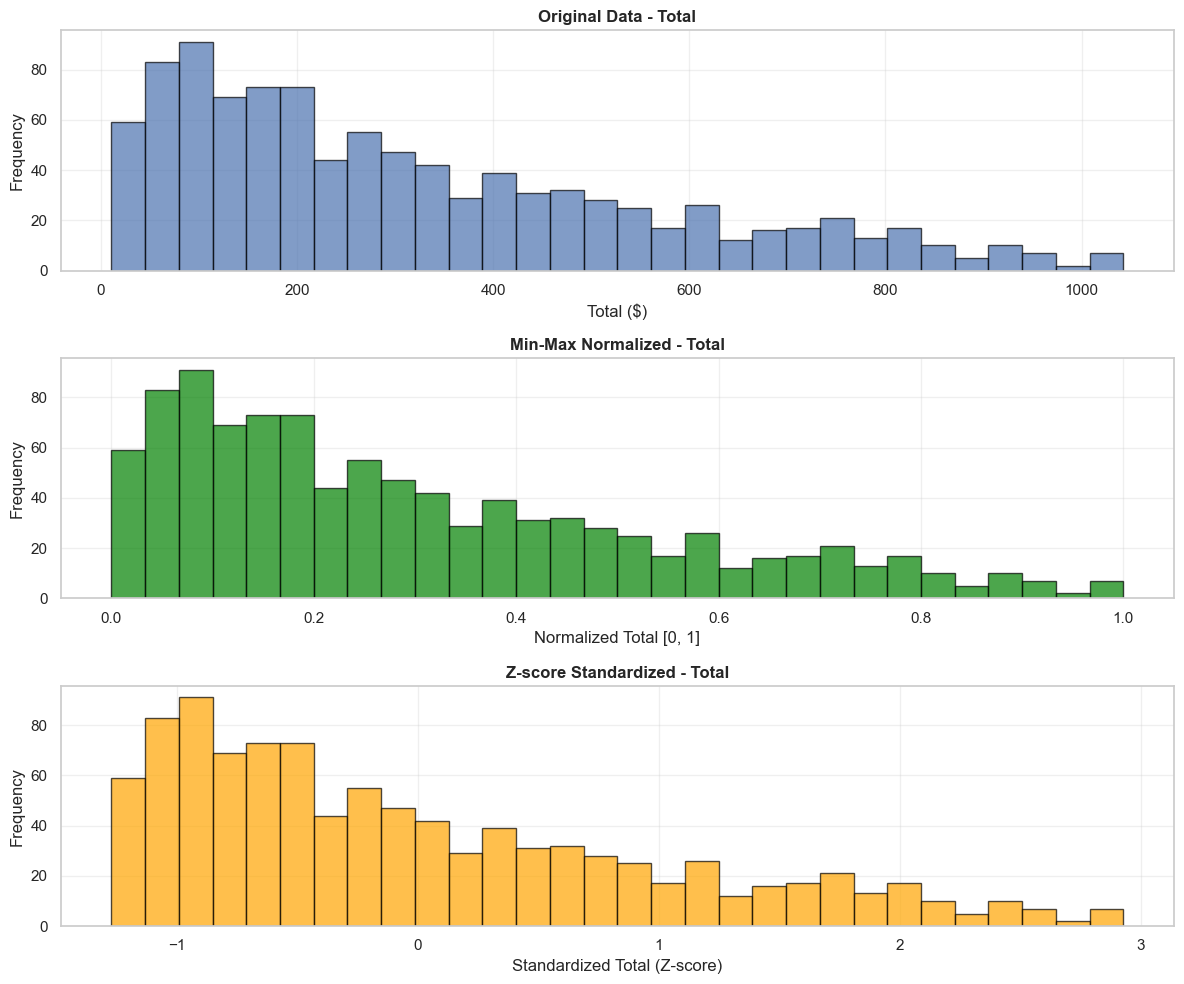


✓ Both normalization methods applied successfully


In [35]:
# Visualize comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Original
df_numeric['Total'].hist(bins=30, ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_title('Original Data - Total', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total ($)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Min-Max
df_minmax['Total'].hist(bins=30, ax=axes[1], edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Min-Max Normalized - Total', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Normalized Total [0, 1]')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

# Z-score
df_standardized['Total'].hist(bins=30, ax=axes[2], edgecolor='black', alpha=0.7, color='orange')
axes[2].set_title('Z-score Standardized - Total', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Standardized Total (Z-score)')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Both normalization methods applied successfully")

## Task 5: Apply PCA (Only if Features Show Correlation)

Steps:
1. Check correlation between numerical features
2. If correlation exists, apply PCA
3. Analyze explained variance

TASK 5: CORRELATION ANALYSIS AND PCA

Correlation Matrix:
               Total  Quantity  Unit price    Rating
Total       1.000000  0.705510    0.633962 -0.036442
Quantity    0.705510  1.000000    0.010778 -0.015815
Unit price  0.633962  0.010778    1.000000 -0.008778
Rating     -0.036442 -0.015815   -0.008778  1.000000


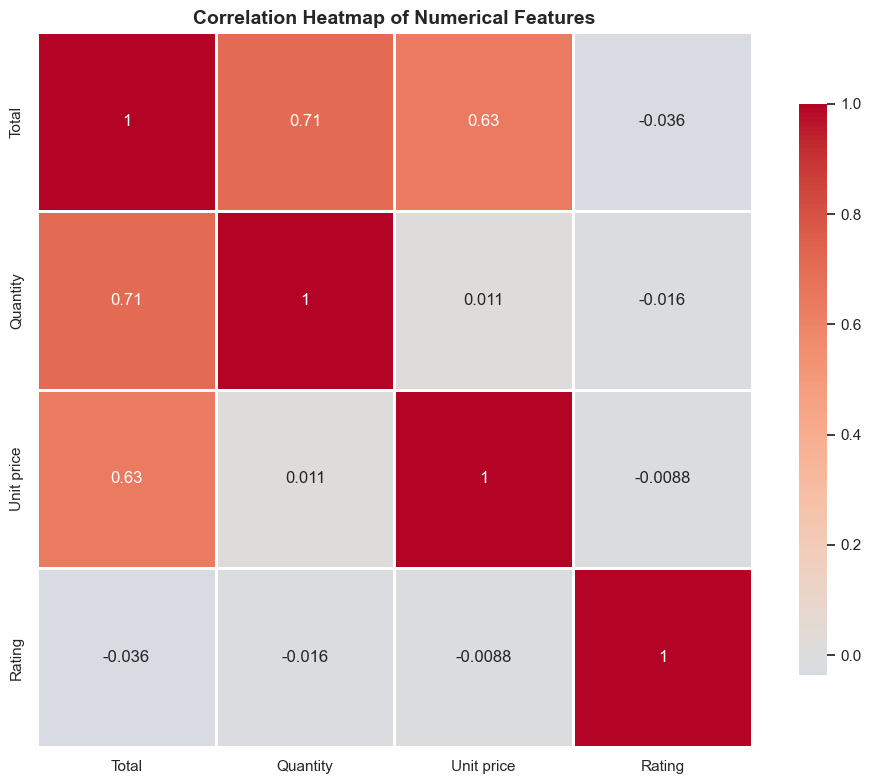


Maximum correlation (excluding diagonal): 0.706
Correlation threshold for PCA: 0.5

✓ Correlation detected (0.706 >= 0.5)
  → Proceeding with PCA...


In [36]:
# Task 5: Check correlation and apply PCA
print("=" * 60)
print("TASK 5: CORRELATION ANALYSIS AND PCA")
print("=" * 60)

# Calculate correlation matrix
correlation_matrix = df_standardized[numerical_features].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize correlation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Check if there's significant correlation
# Get absolute correlations (excluding diagonal)
corr_values = correlation_matrix.abs().values
np.fill_diagonal(corr_values, 0)
max_correlation = corr_values.max()

print(f"\nMaximum correlation (excluding diagonal): {max_correlation:.3f}")

# Decision threshold
correlation_threshold = 0.5
print(f"Correlation threshold for PCA: {correlation_threshold}")

if max_correlation >= correlation_threshold:
    print(f"\n✓ Correlation detected ({max_correlation:.3f} >= {correlation_threshold})")
    print("  → Proceeding with PCA...")
    apply_pca = True
else:
    print(f"\n✗ No significant correlation ({max_correlation:.3f} < {correlation_threshold})")
    print("  → PCA not recommended")
    apply_pca = False


APPLYING PCA

PCA Results (first 5 rows):
        PC1       PC2       PC3       PC4
0  1.207417  1.272745  0.270795  0.064319
1 -1.571986  1.016756  1.466328  0.130477
2  0.141654  0.027679  0.654514 -0.047421
3  0.937254  0.639265  0.771656 -0.001388
4  1.748670 -0.666595 -0.803088  0.072874

Explained Variance Ratio:
  PC1: 0.4889 (48.89%)
  PC2: 0.2500 (25.00%)
  PC3: 0.2469 (24.69%)
  PC4: 0.0142 (1.42%)

Cumulative Explained Variance:
  PC1-PC1: 0.4889 (48.89%)
  PC1-PC2: 0.7389 (73.89%)
  PC1-PC3: 0.9858 (98.58%)
  PC1-PC4: 1.0000 (100.00%)


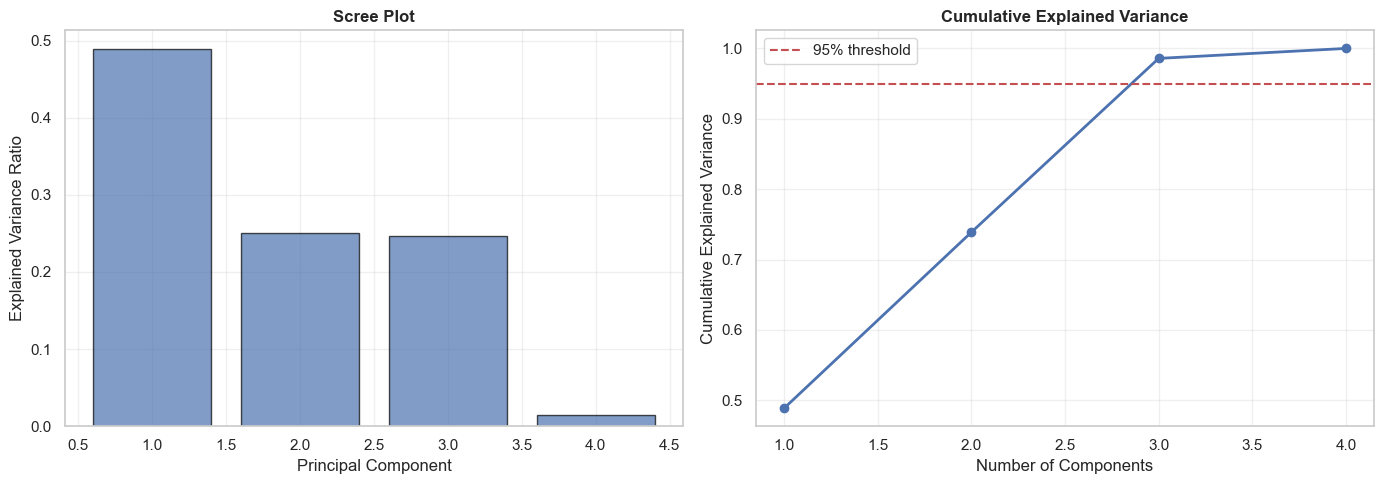


✓ Recommendation: Use 3 components to retain 95% of variance


In [37]:
# Apply PCA if correlation exists
if apply_pca:
    from sklearn.decomposition import PCA
    
    print("\n" + "=" * 60)
    print("APPLYING PCA")
    print("=" * 60)
    
    # Apply PCA
    pca = PCA()
    pca_result = pca.fit_transform(df_standardized[numerical_features])
    
    # Create DataFrame with PCA results
    pca_columns = [f'PC{i+1}' for i in range(len(numerical_features))]
    df_pca = pd.DataFrame(pca_result, columns=pca_columns)
    
    print("\nPCA Results (first 5 rows):")
    print(df_pca.head())
    
    # Explained variance
    print("\nExplained Variance Ratio:")
    for i, var in enumerate(pca.explained_variance_ratio_, 1):
        print(f"  PC{i}: {var:.4f} ({var*100:.2f}%)")
    
    print(f"\nCumulative Explained Variance:")
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    for i, var in enumerate(cumsum, 1):
        print(f"  PC1-PC{i}: {var:.4f} ({var*100:.2f}%)")
    
    # Visualize explained variance
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scree plot
    axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), 
                pca.explained_variance_ratio_, alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance Ratio')
    axes[0].set_title('Scree Plot', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Cumulative variance
    axes[1].plot(range(1, len(cumsum)+1), cumsum, marker='o', linestyle='-', linewidth=2)
    axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Explained Variance')
    axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    n_components_95 = np.argmax(cumsum >= 0.95) + 1
    print(f"\n✓ Recommendation: Use {n_components_95} components to retain 95% of variance")
    
else:
    print("\n⚠ PCA was not applied due to low correlation between features")
    print("  Features are already independent, dimensionality reduction not needed")